# K08_01 – SVM Two Moons und Kernel (Dozent)

## Lernziele
- lineare und nichtlineare SVMs vergleichen
- die Grundidee des **Kernel-Tricks** verstehen
- den Einfluss verschiedener Kernel auf die Entscheidungsgrenze beobachten
- `C` und `gamma` qualitativ einordnen

## Didaktischer Fokus

Der `make_moons`-Datensatz ist ideal, um zu zeigen:

- warum lineare Trennung manchmal nicht ausreicht
- wie Kernel nichtlineare Grenzen ermöglichen
- dass SVMs ihre Stärke besonders bei solchen Datenstrukturen zeigen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

## 1. Two-Moons-Datensatz erzeugen

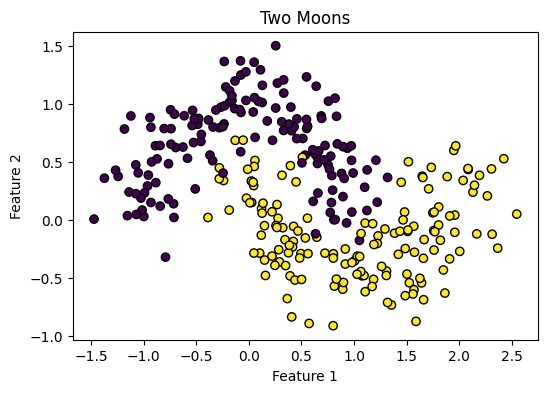

In [2]:
X, y = make_moons(n_samples=300, noise=0.20, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.title("Two Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Trainings- und Testdaten

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 3. Vier Kernel vergleichen

Wir verwenden:
- linear
- polynomial
- rbf
- sigmoid

Skalierung ist dabei wichtig, deshalb arbeiten wir mit einer Pipeline.

In [4]:
models = {
    "linear": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=1.0))
    ]),
    "poly": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=3, C=1.0, gamma="scale"))
    ]),
    "rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ]),
    "sigmoid": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="sigmoid", C=1.0, gamma="scale"))
    ]),
}

In [5]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results.append({"Kernel": name, "Test-Accuracy": acc})

pd.DataFrame(results).round(4)

,Kernel,Test-Accuracy
0,linear,0.8556
1,poly,0.8556
2,rbf,0.9000
3,sigmoid,0.7222


## 4. Entscheidungsgrenzen visualisieren

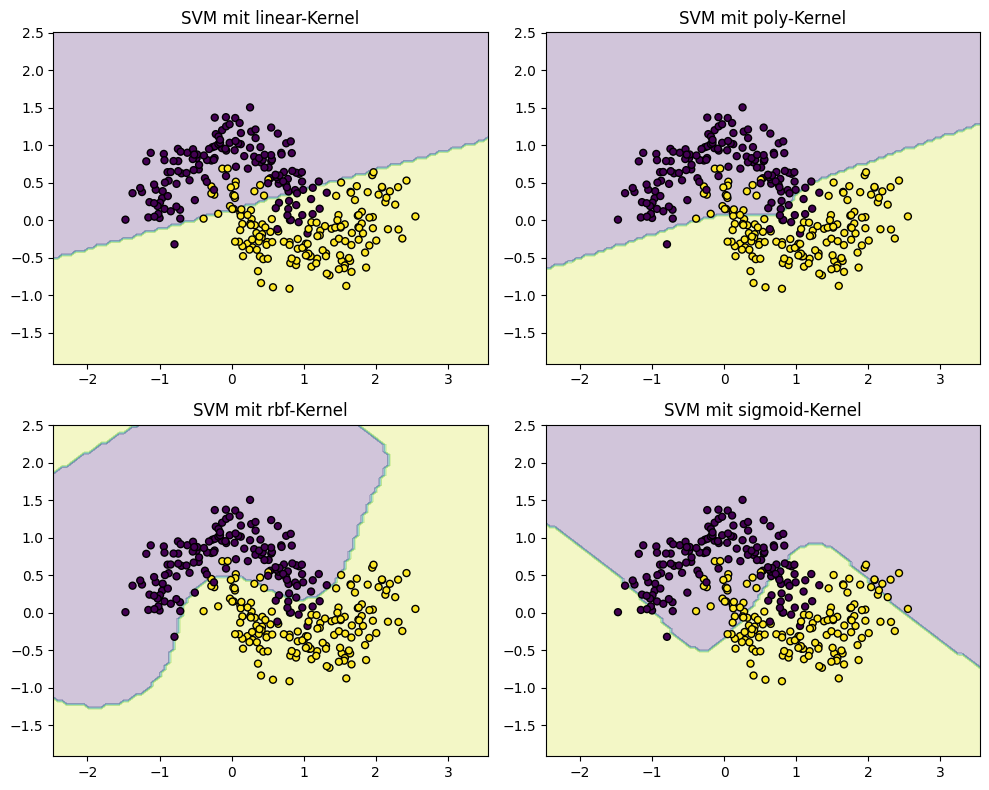

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict", alpha=0.25, ax=ax
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=25)
    ax.set_title(f"SVM mit {name}-Kernel")

plt.tight_layout()
plt.show()

## 5. Einfluss von `C` und `gamma` beim RBF-Kernel

Wir betrachten einige Parameterkombinationen.

In [7]:
param_results = []
settings = [
    (0.1, 0.1),
    (1.0, 0.1),
    (1.0, 1.0),
    (10.0, 1.0),
]

for C, gamma in settings:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma))
    ])
    pipe.fit(X_train, y_train)
    param_results.append({
        "C": C,
        "gamma": gamma,
        "Test-Accuracy": pipe.score(X_test, y_test)
    })

df_params = pd.DataFrame(param_results).round(4)
df_params

,C,gamma,Test-Accuracy
0,0.1,0.1,0.8333
1,1.0,0.1,0.8556
2,1.0,1.0,0.9556
3,10.0,1.0,0.9667


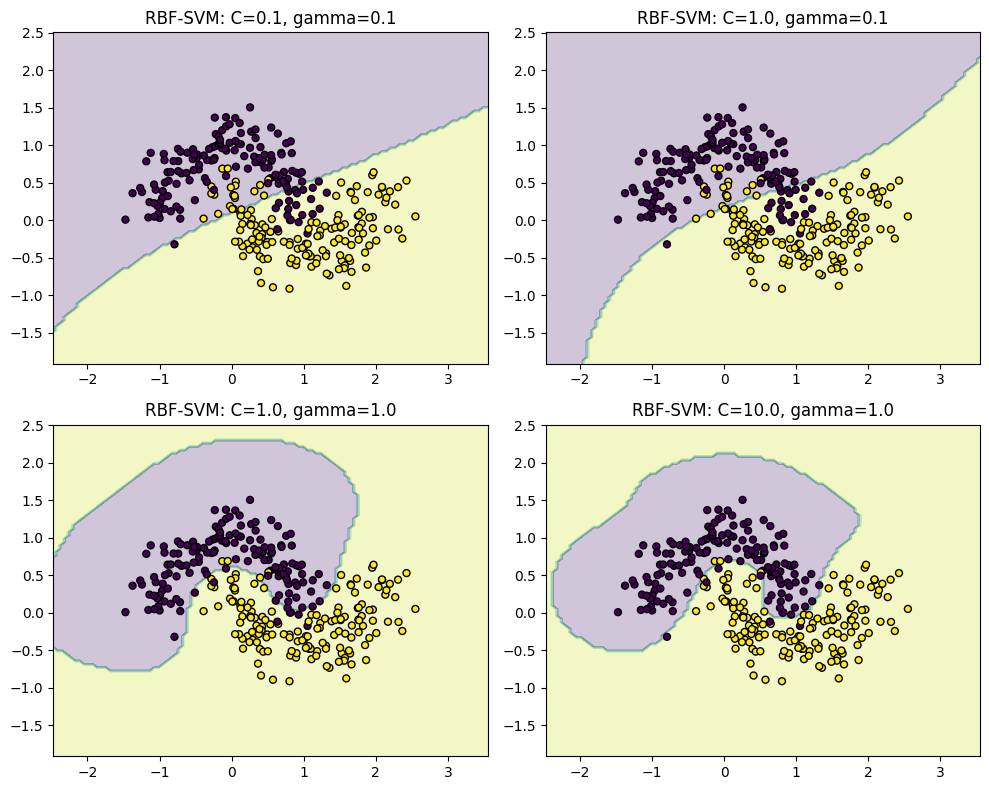

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (C, gamma) in zip(axes, settings):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma))
    ])
    pipe.fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(
        pipe, X, response_method="predict", alpha=0.25, ax=ax
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=25)
    ax.set_title(f"RBF-SVM: C={C}, gamma={gamma}")

plt.tight_layout()
plt.show()

## 6. Längere Übungsaufgabe

1. Erklären Sie, warum der **lineare Kernel** auf Two Moons typischerweise an Grenzen stößt.

2. Vergleichen Sie die Kernel:
   - Welcher wirkt am geeignetsten?
   - Welche Entscheidungsgrenze erscheint am plausibelsten?

3. Interpretieren Sie den Einfluss von `C` und `gamma` beim RBF-Kernel:
   - Wann wirkt die Grenze zu glatt?
   - Wann wirkt sie zu komplex?

4. Formulieren Sie eine schriftliche Zusammenfassung:
   - Was ist die Grundidee des Kernel-Tricks?
   - Warum ist Two Moons ein gutes Demonstrationsbeispiel?

## 7. Fazit

- Die lineare SVM reicht auf nichtlinear trennbaren Daten oft nicht aus.
- Geeignete Kernel können flexible Trennungen ermöglichen.
- Beim RBF-Kernel steuern `C` und `gamma` die Komplexität der Grenze.

## 8. Musterlösung

### Zu 1
Der lineare Kernel kann nur eine lineare Hyperebene erzeugen.  
Die Two-Moons-Struktur ist jedoch nicht linear trennbar, deshalb reicht eine Gerade typischerweise nicht aus.

### Zu 2
Typischerweise ist der **RBF-Kernel** hier besonders geeignet, weil er flexible, glatte nichtlineare Grenzen erzeugen kann.  
Der lineare Kernel wirkt meist zu starr.

### Zu 3
- **Kleines `gamma`** führt oft zu glatteren, großräumigeren Grenzen.
- **Großes `gamma`** kann sehr lokale und komplexe Strukturen erzeugen.
- **Kleines `C`** regularisiert stärker.
- **Großes `C`** orientiert sich stärker an Trainingsfehlern.

### Zu 4
Der Kernel-Trick erlaubt es, nichtlineare Trennungen zu modellieren, ohne die Daten explizit in einen höherdimensionalen Raum transformieren zu müssen.

## 9. Didaktische Hinweise

Dieses Notebook ist das methodische Herzstück des SVM-Kapitels:
- zuerst die **Grenze der linearen SVM**
- dann **nichtlineare Kernel**
- anschließend die qualitative Rolle von `C` und `gamma`